# Patient 1 

In this jupyter notebook the data of patient 1 is loaded, inspected and processed. 

In [1]:
# imports
import pickle
import os
import re 
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import sklearn.metrics as metrics
import scipy as sp
import scipy.stats as stats
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
import logging
import math

# utils functions
from utils.preprocessing import all_have_same_condition, list_iterations, load_complete_session, inspect_session, get_n_epochs, get_iteration_structure, get_n_iterations, load_session_chached, merge_sessions, have_same_preprocessing
from utils.feature_extraction import get_jumping_means, epoch_vectorizer_channelprime
from utils.offline_evaluation import compare_auc_single_trial_interval, compute_auc_with_cv
from utils.online_simulation import online_simulation, online_adaptation_simulation_sw

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')



## Real online simulation

### Simulate session 3 (trained on sessions 1 and 2)

Procedure
1. Only load the runs of calibration sessions 1 and 2 with conditions 6D and 350.
2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)
3. Train a classifier on all calibration data and test it in an online simulation on the data of session 3

Loading file:  data_p1_P1_S1_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  data_p1_P1_S2_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl

Trials of session 1:  12
Trials of session 2:  18
All calibration trials:  30
That is 2700 epochs

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.5307901234567901
AUC SLDA:  0.5837037037037037
AUC BT-LDA:  0.5758271604938271


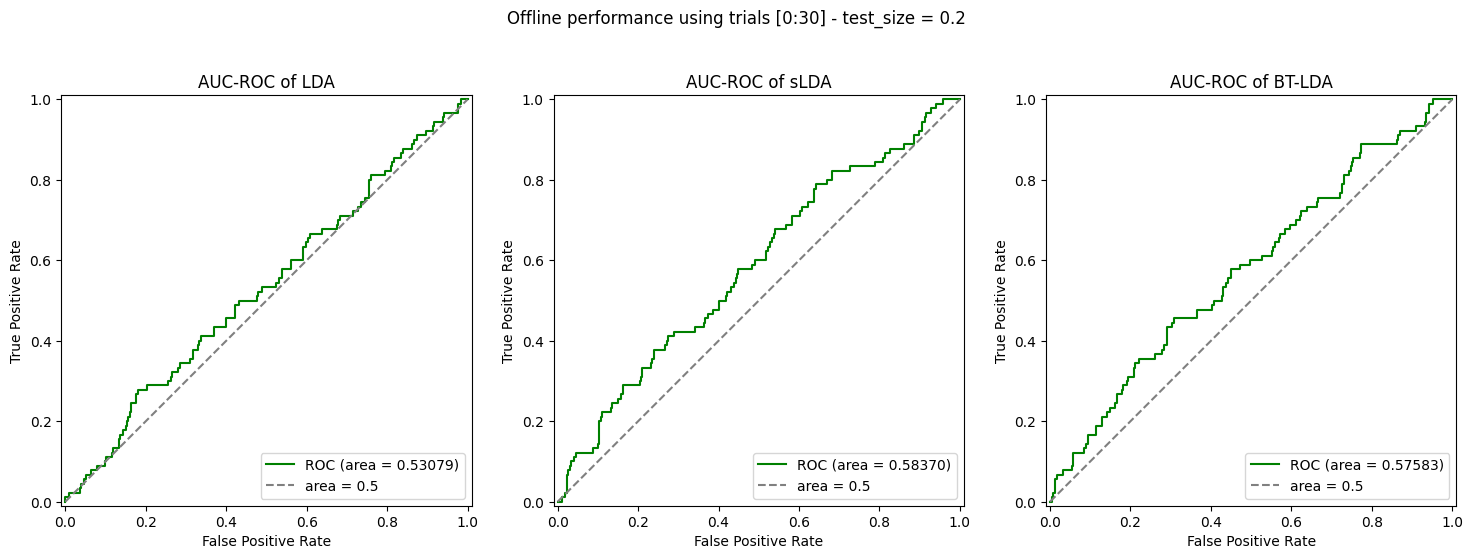

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.5706606665905883
Mean AUC score of sLDA: 	 0.5926908362969345
Mean AUC score of BT-LDA: 	 0.5937643368563904


In [2]:
# 1. Only load the runs of calibration sessions 1 and 2 with conditions 6D and 350.

trials_s1, _,_ = load_session_chached("data_p1/P1_S1/anonymized", selection = "6D_long_350",discard_channels=True)
trials_s2, _,_ = load_session_chached("data_p1/P1_S2/anonymized", selection = "6D_long_350",discard_channels=True)

print("\nTrials of session 1: ",len(trials_s1))
print("Trials of session 2: ",len(trials_s2))

calibration_trials = trials_s1 + trials_s2
print("All calibration trials: ",len(calibration_trials))
print("That is {} epochs\n".format(get_n_epochs(calibration_trials)))

del trials_s1
del trials_s2

# 2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(calibration_trials, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(calibration_trials, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

Loading file:  data_p1_P1_S1_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  data_p1_P1_S2_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S2_anonymized6D_long_350_dc.pkl
All calibration trials:  30
That is 2700 epochs

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.5307901234567901
AUC SLDA:  0.5837037037037037
AUC BT-LDA:  0.5758271604938271


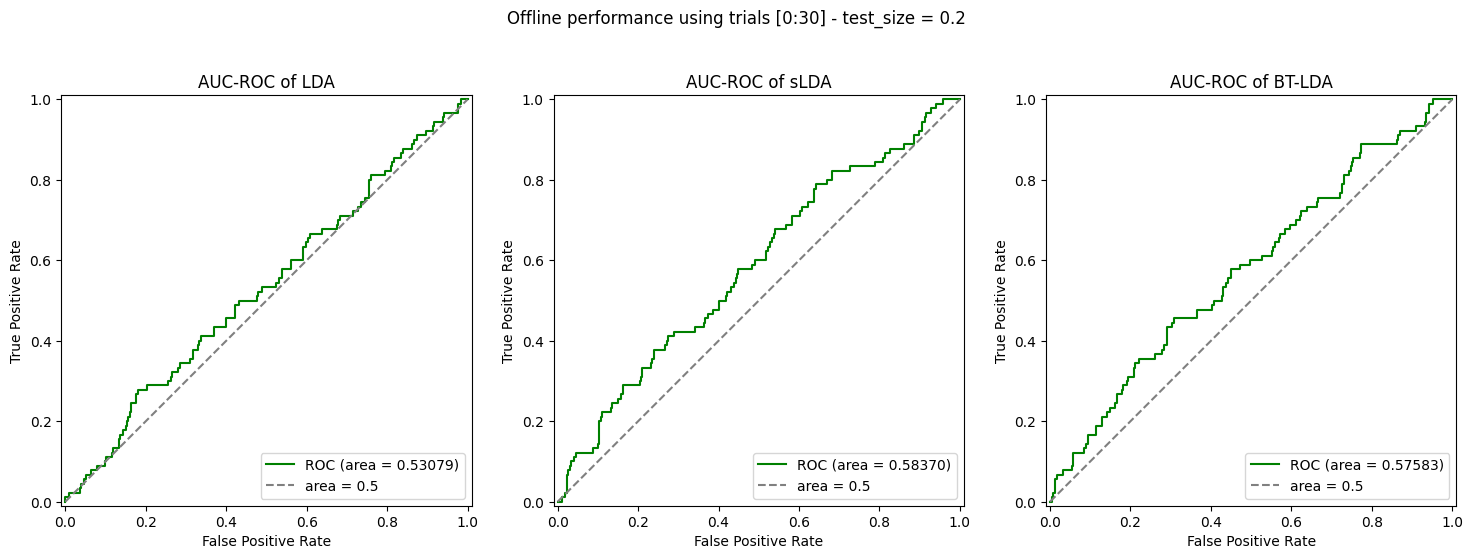

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.5706606665905883
Mean AUC score of sLDA: 	 0.5926908362969345
Mean AUC score of BT-LDA: 	 0.5937643368563904


In [2]:
# 1. Only load the runs of calibration sessions 1 and 2 with conditions 6D and 350.

data_s1 = load_session_chached("data_p1/P1_S1/anonymized", selection = "6D_long_350",discard_channels=True)
data_s2 = load_session_chached("data_p1/P1_S2/anonymized", selection = "6D_long_350",discard_channels=True)

data_s12 = merge_sessions(data_s1, data_s2)

calibration_trials = data_s12.get('trials')
print("All calibration trials: ",len(calibration_trials))
print("That is {} epochs\n".format(get_n_epochs(calibration_trials)))

# 2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(calibration_trials, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(calibration_trials, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
(1197, 6)
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/8

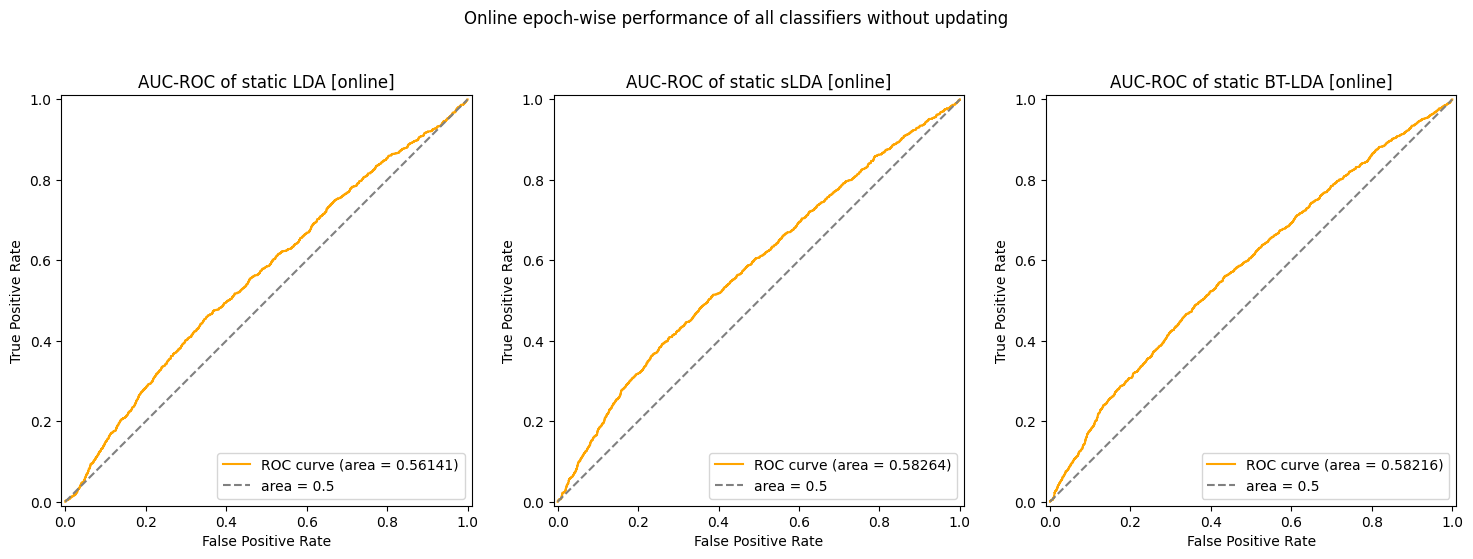

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.36905
Accuracy SLDA: 0.51190
Accuracy BT-LDA: 0.47619


In [3]:
# online simulation static (trained on sessions 1,2 - applied on session 3)
data_path = "data_p1/P1_S3/anonymized"
data_s3 = load_session_chached(data_path, selection = None)
trials_s3 = data_s3.get('trials')
pca = data_s12.get('preprocessing')
fca = data_s12.get('filenames')
pon = data_s3.get('preprocessing')
fon = data_s3.get('filenames')

online_words_s3 = online_simulation(raw_calibration_trials = calibration_trials, online_trials = trials_s3, log_process="online_static_s3.log", preprocessing_calibration=pca, preprocessing_online=pon, filenames_calibration=fca, filenames_online=fon)


In [5]:
inspect_session(data_path="data_p1/P1_S3/anonymized")

Condition per run: 
['6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D', '6D']
['350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350', '350']
All conditions of this session are the same:  True
Number of iterations per trial:
Run 0: [15  8 15 15 15 15]
Run 1: [15 15 15 15 15 15]
Run 2: [15 15 15 14 15 15]
Run 3: [15  8 15 15 15 15]
Run 4: [15  8  8 15 15 15]
Run 5: [15 15 15 15 14 15]
Run 6: [10 15 15 15 15 15]
Run 7: [15 15 15 15 15 15]
Run 8: [15 15 15 15 15 15]
Run 9: [15 15 15 15 15 15]
Run 10: [15 15 15 15 15 10]
Run 11: [15 15 15 13 15 15]
Run 12: [15 15 12 15 15  8]
Run 13: [15 15 10 15 15  9]


Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
(1197, 6)
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/8

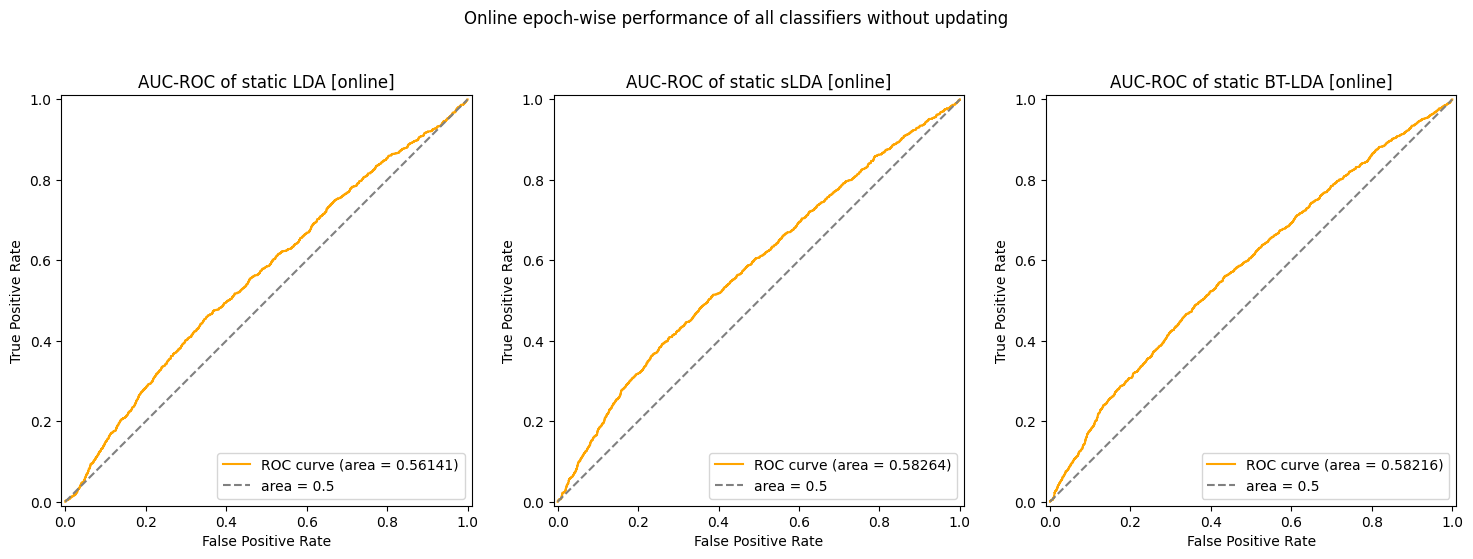

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.36905
Accuracy SLDA: 0.51190
Accuracy BT-LDA: 0.47619


In [4]:
# online simulation static (trained on sessions 1,2 - applied on session 3)
trials_s3, iterations_s3, epochs_s3 = load_session_chached("data_p1/P1_S3/anonymized", selection = None)
online_words_s3 = online_simulation(raw_calibration_trials = calibration_trials, online_trials = trials_s3, log_process="online_static_s3.log")


Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 68

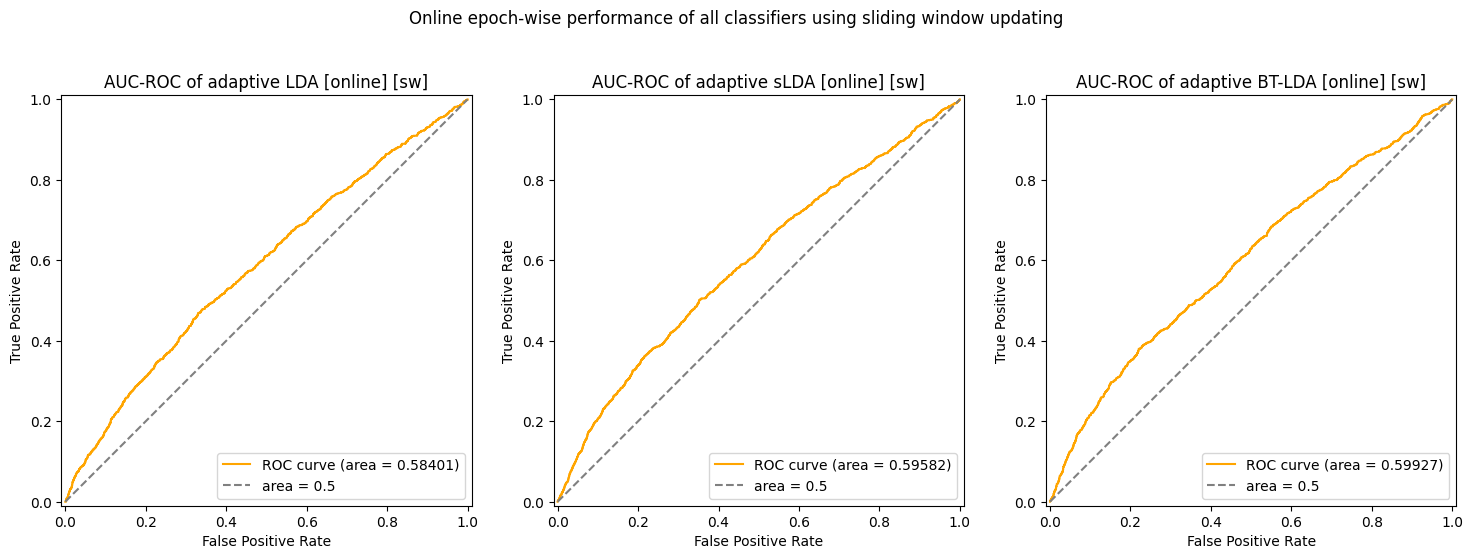

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.53571
Accuracy SLDA: 0.55952
Accuracy BT-LDA: 0.57143


In [4]:
# Adaptation: sliding window

# 4. Train a classifier on all calibration data and test it in an online simulation *with adaptation* on the data of session 3

trials_s3, iterations_s3, epochs_s3 = load_session_chached("data_p1/P1_S3/anonymized", selection = None)

online_words_s3 = online_adaptation_simulation_sw(raw_calibration_trials=calibration_trials, online_trials=trials_s3, log_process="online_adaptive_sw_s3.log")


## Adaptation

## Session 3

In [ ]:
# 1. Only load the runs of session 4 as training data.
trials_s1, _, _ = load_session_chached("data_p1/P1_S1/anonymized", selection = "6D_long_350",discard_channels=True)
trials_s2, _, _ = load_session_chached("data_p1/P1_S2/anonymized", selection = "6D_long_350",discard_channels=True)

print("\nTrials of session 1: ",len(trials_s1))
print("Trials of session 2: ",len(trials_s2))

calibration_trials = trials_s1 + trials_s2
print("All calibration trials: ",len(calibration_trials))
print("That is {} epochs\n".format(get_n_epochs(calibration_trials)))

del trials_s1
del trials_s2

# 2. Train a classifier on the loaded calibration data and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(calibration_trials, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(calibration_trials, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 3
trials_s3, _, _ = load_session_chached("data_p1/P1_S3/anonymized", selection = None)

online_words_s3 = online_simulation(raw_calibration_trials=calibration_trials, online_trials=trials_s3, log_process="online_static_s3.log")

# Adaptation: sliding window
# 4. Train a classifier on all calibration data and test it in an online simulation *with adaptation* on the data of session 3

online_words_s3 = online_adaptation_simulation_sw(raw_calibration_trials=calibration_trials, online_trials=trials_s3, log_process="online_adaptive_sw_s3.log")

## Session 4 


Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
All calibration trials:  84
That is 7182 epochs

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6471140883341133
AUC SLDA:  0.6523843784270856
AUC BT-LDA:  0.6608957746872403


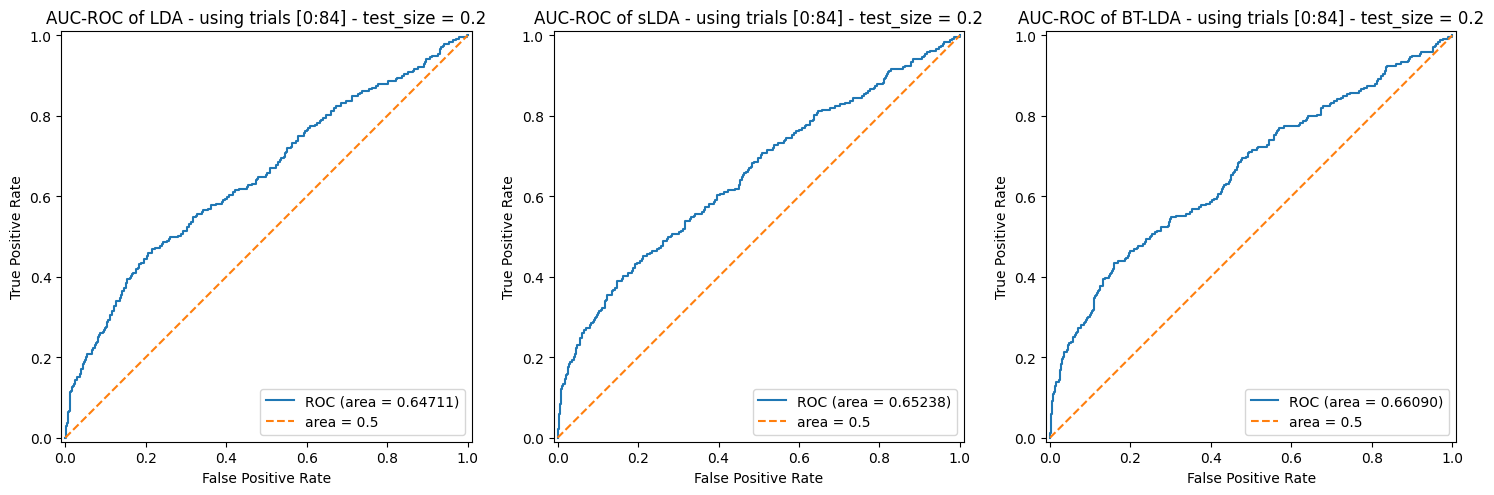

Mean AUC score of LDA: 		 0.6092158900971332
Mean AUC score of sLDA: 	 0.6113796577895476
Mean AUC score of BT-LDA: 	 0.6146664599894142
Loading file:  data_p1_P1_S4_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S4_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S4_anonymized.pkl
(1371, 6)
trial 0/102
trial 1/102
trial 2/102
trial 3/102
trial 4/102
trial 5/102
trial 6/102
trial 7/102
trial 8/102
trial 9/102
trial 10/102
trial 11/102
trial 12/102
trial 13/102
trial 14/102
trial 15/102
trial 16/102
trial 17/102
trial 18/102
trial 19/102
trial 20/102
trial 21/102
trial 22/102
trial 23/102
trial 24/102
trial 25/102
trial 26/102
trial 27/102
trial 28/102
trial 29/102
trial 30/102
trial 31/102
trial 32/102
trial 33/102
trial 34/102
trial 35/102
trial 36/102
trial 37/102
trial 38/102
trial 39/102
trial 40/102
trial 41/102
trial 42/102
trial 43/102
trial 44/102
trial 45/102
trial 46/102
trial 47/102
trial 48/102
trial 49/102
trial 50/102
trial 51/102
t

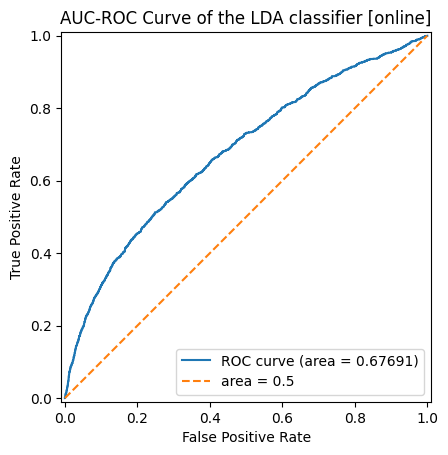

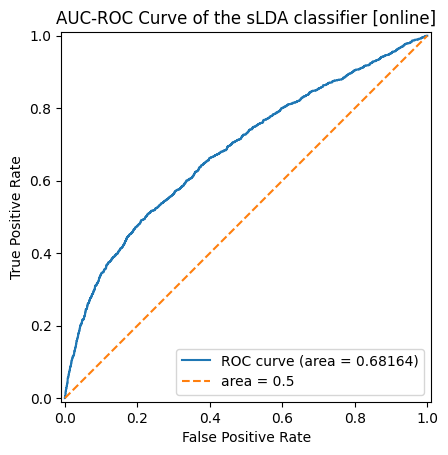

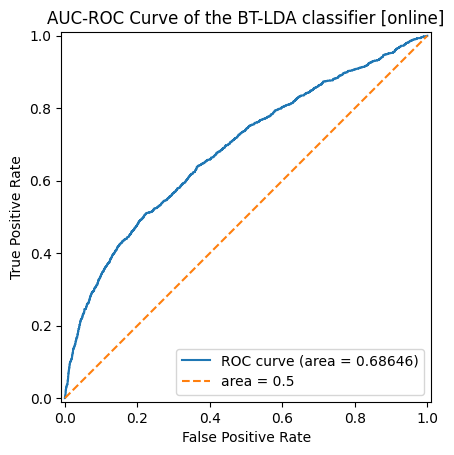

Accuracy LDA: 0.71569
Accuracy SLDA: 0.68627
Accuracy BT-LDA: 0.69608


In [157]:
# 1. Only load the runs of session 3 as training data.
calibration_trials, _, _ = load_session_chached("data_p1/P1_S3/anonymized")

print("All calibration trials: ",len(calibration_trials))
print("That is {} epochs\n".format(get_n_epochs(calibration_trials)))

# 2. Train a classifier and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(calibration_trials, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(calibration_trials, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 4
trials_s4, _, _ = load_session_chached("data_p1/P1_S4/anonymized", selection = None)

online_words_s4 = online_simulation(raw_calibration_trials=calibration_trials, online_trials=trials_s4, log_process="online_static_s4.log")

Loading file:  data_p1_P1_S3_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S3_anonymized.pkl
Loading file:  data_p1_P1_S4_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S4_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S4_anonymized.pkl
(1371, 6)
trial 0/102
trial 1/102
trial 2/102
trial 3/102
trial 4/102
trial 5/102
trial 6/102
trial 7/102
trial 8/102
trial 9/102
trial 10/102
trial 11/102
trial 12/102
trial 13/102
trial 14/102
trial 15/102
trial 16/102
trial 17/102
trial 18/102
trial 19/102
trial 20/102
trial 21/102
trial 22/102
trial 23/102
trial 24/102
trial 25/102
trial 26/102
trial 27/102
trial 28/102
trial 29/102
trial 30/102
trial 31/102
trial 32/102
trial 33/102
trial 34/102
trial 35/102
trial 36/102
trial 37/102
trial 38/102
trial 39/102
trial 40/102
trial 41/102
trial 42/102
trial 43/102
trial 44/102
trial 45/102
trial 46/102
trial 47/102
tria

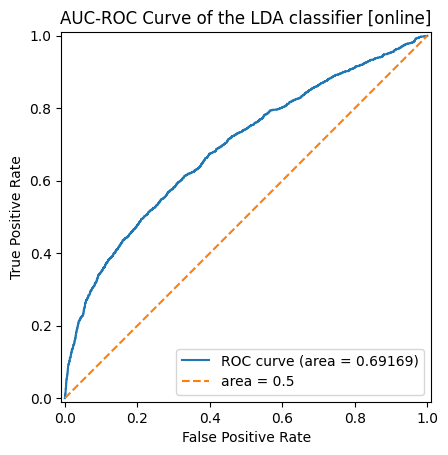

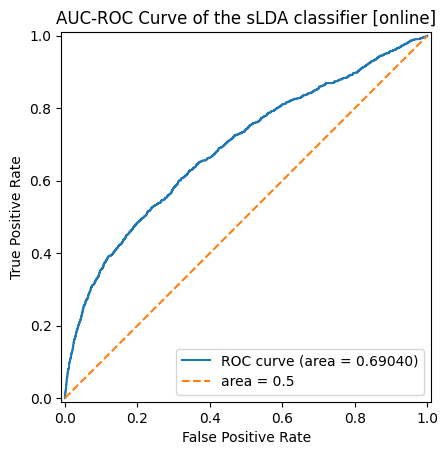

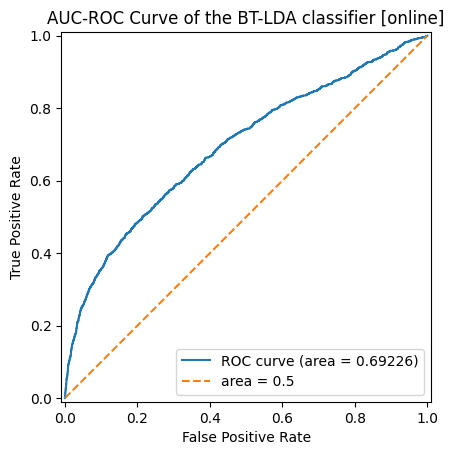

Accuracy LDA: 0.69608
Accuracy SLDA: 0.67647
Accuracy BT-LDA: 0.68627


In [202]:
# Adaptation: sliding window

# 4. Train a classifier on all calibration data and test it in an online simulation *with adaptation* on the data of session 3
trials_s3, iterations_s3, epochs_s3 = load_session_chached("data_p1/P1_S3/anonymized", selection = None)
trials_s4, _, _ = load_session_chached("data_p1/P1_S4/anonymized", selection = None)

online_words_s4 = online_adaptation_simulation_sw(raw_calibration_trials=trials_s3, online_trials=trials_s4, log_process="online_adaptive_sw_s4.log")



## Session 5

Loading file:  data_p1_P1_S4_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S4_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S4_anonymized.pkl


All calibration trials:  102
That is 8226 epochs

AUC scores computed using a single train_test_split with test_size = 0.2
AUC LDA:  0.6949921261518163
AUC SLDA:  0.7073615160349853
AUC BT-LDA:  0.7061032963759017


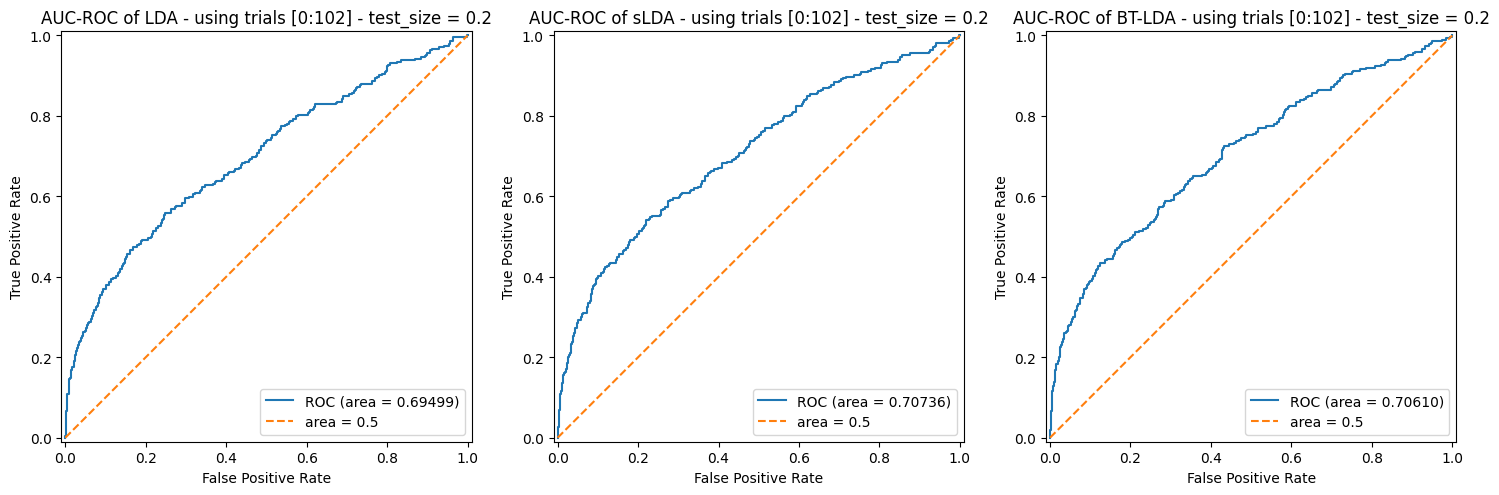

Mean AUC score of LDA: 		 0.6941367469916186
Mean AUC score of sLDA: 	 0.6940095798380344
Mean AUC score of BT-LDA: 	 0.6949448362732878
Loading file:  data_p1_P1_S5_anonymized
Corresponding .pkl file:  cache/data_p1_P1_S5_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p1_P1_S5_anonymized.pkl
(1055, 6)
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial

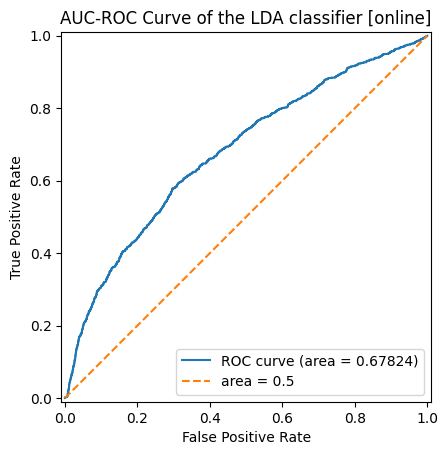

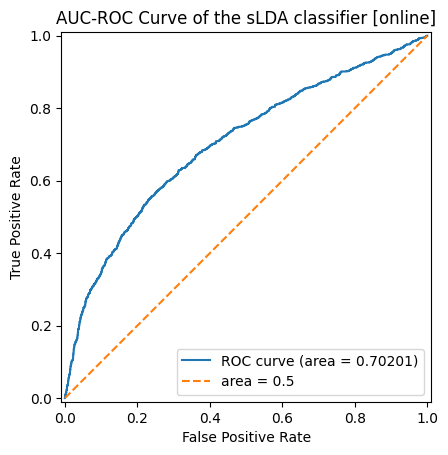

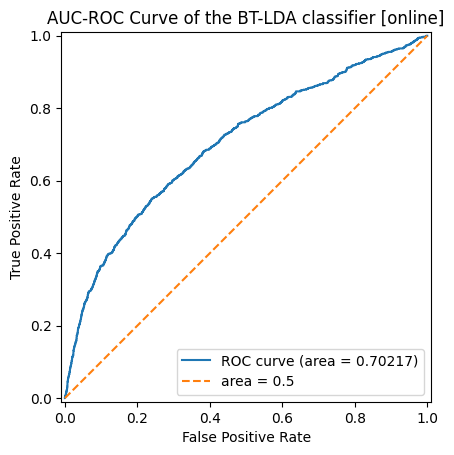

Accuracy LDA: 0.66667
Accuracy SLDA: 0.70238
Accuracy BT-LDA: 0.71429
(1055, 6)
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 68/84
trial 69/84
trial 70/84
trial 71/84
trial 72/84
trial 73/84
trial 74/84
trial 75/84
trial 76/84
trial 

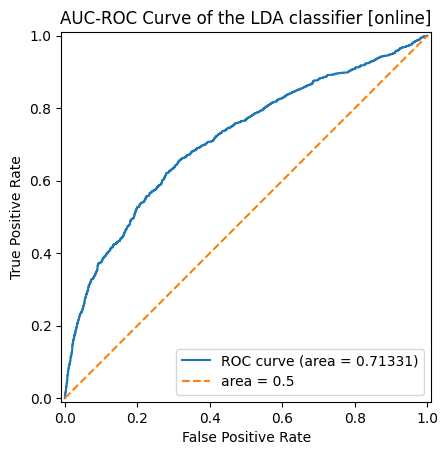

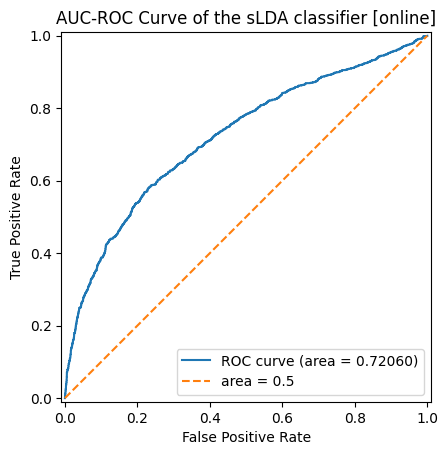

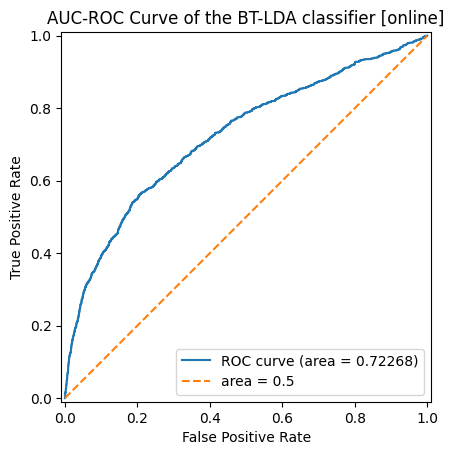

Accuracy LDA: 0.73810
Accuracy SLDA: 0.73810
Accuracy BT-LDA: 0.73810


In [203]:
# 1. Only load the runs of session 4 as training data.
trials_s4, _, _ = load_session_chached("data_p1/P1_S4/anonymized")

print("All calibration trials: ",len(trials_s4))
print("That is {} epochs\n".format(get_n_epochs(trials_s4)))

# 2. Train a classifier and evaluate the offline performance (using either train_test_split or cv)

clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
compare_auc_single_trial_interval(trials_s4, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)

compute_auc_with_cv(trials_s4, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

# 3. Train a classifier on all calibration data and test it in an online simulation on the data of session 5
trials_s5, _, _ = load_session_chached("data_p1/P1_S5/anonymized", selection = None)

online_words_s5 = online_simulation(raw_calibration_trials=trials_s4, online_trials=trials_s5, log_process="online_static_s5.log")

# Adaptation: sliding window
# 4. Train a classifier on all calibration data and test it in an online simulation *with adaptation* on the data of session 3

online_words_s5 = online_adaptation_simulation_sw(raw_calibration_trials=trials_s4, online_trials=trials_s5, log_process="online_adaptive_sw_s5.log")
